  d = (1, 1, 1, 1)   q0 = (0, 0)
  --------------------------------------------------
     #     sigma           Q1        Q2  status
  --------------------------------------------------
     1   (+,+,+,+)     -1.000     1.000  interior
     2   (+,+,+,-)     -1.000    -1.000  interior
     3   (+,+,-,+)     -3.000     1.000  hull
     4   (+,+,-,-)     -3.000    -1.000  hull
     5   (+,-,+,+)      1.000    -1.000  interior
     6   (+,-,+,-)      1.000    -3.000  hull
     7   (+,-,-,+)     -1.000    -1.000  interior
     8   (+,-,-,-)     -1.000    -3.000  hull
     9   (-,+,+,+)      1.000     3.000  hull
    10   (-,+,+,-)      1.000     1.000  interior
    11   (-,+,-,+)     -1.000     3.000  hull
    12   (-,+,-,-)     -1.000     1.000  interior
    13   (-,-,+,+)      3.000     1.000  hull
    14   (-,-,+,-)      3.000    -1.000  hull
    15   (-,-,-,+)      1.000     1.000  interior
    16   (-,-,-,-)      1.000    -1.000  interior

  Hull: 8-gon   (8 of 16 sigma-points on hul

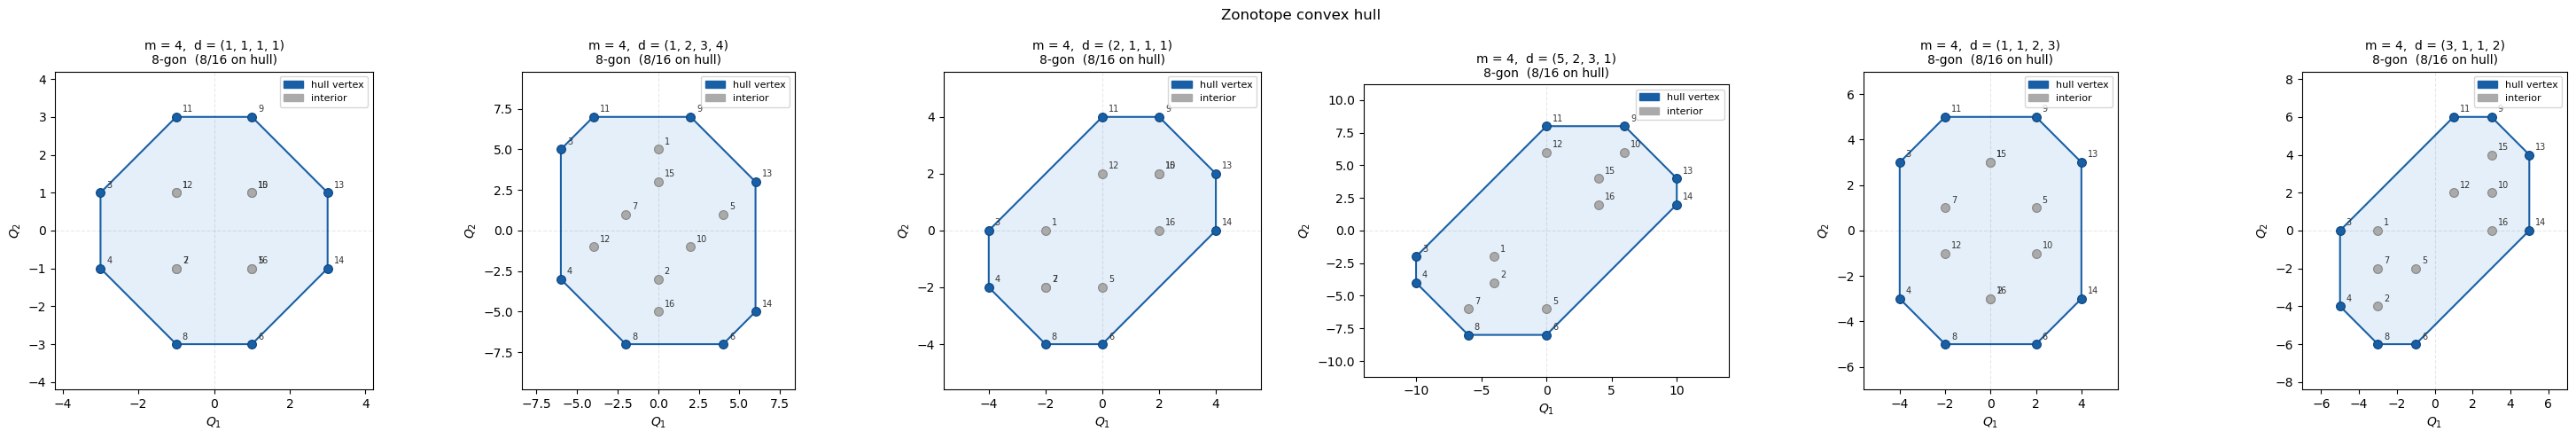

In [10]:
"""
Generalized zonotope convex-hull analysis.

A zonotope is the Minkowski sum of line segments:

    Z = q0 + sum_e [-d_e * g_e , +d_e * g_e]

with vertices located at

    q^sigma = q0 + sum_e sigma_e * d_e * g_e ,      sigma_e in {-1,+1}.

This module works for ANY number of generators, ANY generator matrix,
and any ambient dimension (hull analysis is dimension-agnostic; plotting
is provided for 2D).

Main entry points
-----------------
Zonotope(generators, d=None, q0=None)   -- the central object
    .vertices(orientations=None)        -- sigma-vertices (all 2^m by default)
    .analyse(orientations=None)         -- hull + on-hull classification
    .direction_dependencies()           -- general replacement for the old
                                           hard-coded check_direction_dependency()
    .predicted_hull_sides()             -- 2 * (# distinct directions) in 2D
plot(zonotope_or_list, ...)             -- side-by-side hull plots (2D)
print_table(zonotope, ...)              -- vertex table with hull status
"""

from itertools import product

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import ConvexHull, QhullError

# ---------------------------------------------------------------------------
# Example Data (for the non-graphical matroid)
# ---------------------------------------------------------------------------

ORIENTATIONS = [
    ("1", [+1, +1, -1, +1]),
    ("2", [+1, +1, -1, -1]),
    ("3", [+1, -1, +1, -1]),
    ("4", [+1, -1, -1, -1]),
    ("5", [-1, +1, +1, +1]),
    ("6", [-1, +1, -1, +1]),
    ("7", [-1, -1, +1, +1]),
    ("8", [-1, -1, +1, -1]),
]

# Columns of the generator matrix  (each row is a_e^B)
DIRS = np.array([
    [-1, -1],   # a_1^B
    [-1, +1],   # a_2^B
    [+1,  0],   # a_3^B
    [ 0, +1],   # a_4^B
], dtype=float)

# ---------------------------------------------------------------------------
# Core object
# ---------------------------------------------------------------------------

class Zonotope:
    """
    Parameters
    ----------
    generators : (m, dim) array-like
        One row per generator g_e (any m, any dim >= 1).
    d : array-like of length m, optional
        Segment half-lengths d_e (default: all ones).
    q0 : array-like of length dim, optional
        Base point (default: origin).
    """

    def __init__(self, generators, d=None, q0=None):
        self.G = np.atleast_2d(np.asarray(generators, dtype=float))
        self.m, self.dim = self.G.shape
        self.d = np.ones(self.m) if d is None else np.asarray(d, dtype=float)
        if self.d.shape != (self.m,):
            raise ValueError(f"d must have length {self.m}, got {self.d.shape}")
        self.q0 = (np.zeros(self.dim) if q0 is None
                   else np.asarray(q0, dtype=float))
        if self.q0.shape != (self.dim,):
            raise ValueError(f"q0 must have length {self.dim}")

    # -- effective (scaled) generators --------------------------------------
    @property
    def scaled(self):
        """d_e * g_e, shape (m, dim)."""
        return self.d[:, None] * self.G

    # -- sign vectors --------------------------------------------------------
    def all_orientations(self):
        """All 2^m sign vectors as a list of (label, sigma) pairs."""
        out = []
        for i, signs in enumerate(product([+1, -1], repeat=self.m), start=1):
            out.append((str(i), np.array(signs, dtype=float)))
        return out

    # -- vertices ------------------------------------------------------------
    def vertices(self, orientations=None):
        """
        Vertex candidates q^sigma for the given orientations
        (default: all 2^m sign vectors).

        Returns
        -------
        labels : list of str
        verts  : (n, dim) array
        """
        if orientations is None:
            orientations = self.all_orientations()
        labels, verts = [], []
        for name, sigma in orientations:
            sigma = np.asarray(sigma, dtype=float)
            if sigma.shape != (self.m,):
                raise ValueError(
                    f"orientation {name!r} has length {len(sigma)}, "
                    f"expected {self.m}")
            labels.append(name)
            verts.append(self.q0 + sigma @ self.scaled)
        return labels, np.array(verts)

    # -- direction dependency (general) --------------------------------------
    def direction_dependencies(self, tol=1e-9, verbose=True):
        """
        General analysis of linear structure among the generators.
        Replaces the old hard-coded check a_4 = a_2 + a_3.

        Reports
        -------
        rank              : rank of the generator matrix
        parallel_classes  : generators grouped by direction (up to sign);
                            parallel generators fuse into a single zonotope
                            direction, reducing the number of hull sides
        null_space        : basis of linear relations  c . G = 0  (each row c
                            is one exact dependency among the generators)
        n_directions      : number of distinct (non-parallel, non-zero)
                            directions among the scaled generators
        """
        S = self.scaled

        # ---- rank ----
        rank = np.linalg.matrix_rank(S, tol=tol)

        # ---- clean dependency relations via RREF of S^T ----
        # Columns of S^T are the scaled generators. RREF expresses every
        # non-pivot generator as a combination of the pivot ones, giving
        # human-readable relations like  g_4 = g_2 + g_3.
        pivots, coeffs = _rref_dependencies(S.T, tol=tol)
        # Each entry of `relations` is (dependent_index, {pivot_index: coeff})
        relations = []
        pivot_set = set(pivots)
        for e in range(self.m):
            if e in pivot_set:
                continue
            combo = {p: coeffs[e][k] for k, p in enumerate(pivots)
                     if abs(coeffs[e][k]) > tol}
            relations.append((e, combo))

        # ---- group by direction (up to sign) ----
        classes = []                     # list of lists of generator indices
        reps = []                        # representative unit vectors
        for e in range(self.m):
            v = S[e]
            n = np.linalg.norm(v)
            if n < tol:                  # zero generator: contributes nothing
                classes.append(None)
                continue
            u_e = v / n
            placed = False
            for ci, r in enumerate(reps):
                if (np.linalg.norm(u_e - r) < tol
                        or np.linalg.norm(u_e + r) < tol):
                    classes[ci].append(e) if isinstance(classes[ci], list) \
                        else None
                    # find the class list to append to
                    placed = True
                    break
            if not placed:
                reps.append(u_e)
                classes.append([e])

        # tidy: build the actual grouping
        parallel_classes = []
        reps2 = []
        used = set()
        for e in range(self.m):
            if e in used:
                continue
            v = S[e]
            n = np.linalg.norm(v)
            if n < tol:
                parallel_classes.append(("zero", [e]))
                used.add(e)
                continue
            u_e = v / n
            group = [e]
            used.add(e)
            for f in range(e + 1, self.m):
                if f in used:
                    continue
                w = S[f]
                nf = np.linalg.norm(w)
                if nf < tol:
                    continue
                u_f = w / nf
                if (np.linalg.norm(u_e - u_f) < tol
                        or np.linalg.norm(u_e + u_f) < tol):
                    group.append(f)
                    used.add(f)
            parallel_classes.append((u_e, group))
            reps2.append(u_e)

        n_directions = sum(1 for r, _ in parallel_classes
                           if not isinstance(r, str))

        if verbose:
            print("Generator dependency analysis")
            print("-" * 46)
            print(f"  generators           : m = {self.m}, dim = {self.dim}")
            print(f"  rank of generator set: {rank}"
                  + ("  (full)" if rank == min(self.m, self.dim) else ""))
            print(f"  distinct directions  : {n_directions}")
            for rep, group in parallel_classes:
                idx = ", ".join(f"g_{e+1}" for e in group)
                if isinstance(rep, str):
                    print(f"    zero generator(s)  : {idx}")
                elif len(group) > 1:
                    print(f"    parallel class     : {{{idx}}}  "
                          f"direction ≈ {np.round(rep, 6)}")
                else:
                    print(f"    single             : {idx}       "
                          f"direction ≈ {np.round(rep, 6)}")
            if relations:
                print(f"  {len(relations)} dependency relation(s) "
                      f"(scaled generators d_e*g_e):")
                for e, combo in relations:
                    if not combo:
                        print(f"    d_{e+1}g_{e+1} = 0  (zero generator)")
                        continue
                    rhs = " + ".join(
                        (f"d_{p+1}g_{p+1}" if abs(c - 1) < tol else
                         f"(-1)·d_{p+1}g_{p+1}" if abs(c + 1) < tol else
                         f"({c:+.4g})·d_{p+1}g_{p+1}")
                        for p, c in sorted(combo.items()))
                    print(f"    d_{e+1}g_{e+1} = {rhs}")
            else:
                print("  generators are linearly independent")
            if self.dim == 2:
                print(f"  => hull is at most a "
                      f"{2 * n_directions}-gon (2 x #directions).")
            print()

        return dict(rank=rank,
                    relations=relations,
                    pivots=pivots,
                    parallel_classes=parallel_classes,
                    n_directions=n_directions)

    def predicted_hull_sides(self, tol=1e-9):
        """For dim == 2: exact side count = 2 x (# distinct directions)."""
        info = self.direction_dependencies(tol=tol, verbose=False)
        return 2 * info["n_directions"]

    # -- hull analysis --------------------------------------------------------
    def analyse(self, orientations=None, tol=1e-9):
        """
        Compute vertices, convex hull, and classify each sigma-vertex.

        Returns dict with keys:
            labels, vertices, hull, hull_pts, on_hull, n_sides,
            collinear, unique_pts
        """
        labels, verts = self.vertices(orientations)

        _, unique_idx = np.unique(verts.round(9), axis=0, return_index=True)
        unique_pts = verts[sorted(unique_idx)]

        base = dict(labels=labels, vertices=verts,
                    on_hull=np.zeros(len(verts), bool),
                    n_sides=0, collinear=[], hull=None,
                    hull_pts=np.zeros((0, self.dim)),
                    unique_pts=unique_pts)

        if len(unique_pts) <= self.dim:
            return base                      # degenerate: no full-dim hull

        try:
            hull = ConvexHull(unique_pts)
        except QhullError:                   # flat / degenerate configuration
            return base

        if self.dim == 2:
            hull_pts = unique_pts[hull.vertices]           # ordered corners
            on_hull = _points_on_hull_2d(verts, hull_pts)
            collinear = _find_collinear(hull_pts)
            n_sides = len(hull.vertices)
        else:
            corner_set = unique_pts[hull.vertices]
            on_hull = np.array([
                np.any(np.all(np.abs(corner_set - p) < 1e-9, axis=1))
                for p in verts])
            collinear = []
            n_sides = len(hull.simplices)    # facet count in dim > 2

        base.update(hull=hull, hull_pts=hull_pts if self.dim == 2
                    else corner_set,
                    on_hull=on_hull, n_sides=n_sides, collinear=collinear)
        return base


# ---------------------------------------------------------------------------
# Linear-algebra helper: RREF-based dependencies
# ---------------------------------------------------------------------------

def _rref_dependencies(M, tol=1e-9):
    """
    Reduced row echelon form of M (dim x m), treating COLUMNS as vectors.

    Returns
    -------
    pivots : list of pivot column indices (an independent subset of columns)
    coeffs : (m, r) array; row e gives the coefficients expressing column e
             as a combination of the pivot columns:
                 col_e = sum_k coeffs[e, k] * col_{pivots[k]}
             (For pivot columns this is a unit vector.)
    """
    A = np.array(M, dtype=float)
    n_rows, n_cols = A.shape
    R = A.copy()
    pivots = []
    row = 0
    for col in range(n_cols):
        if row >= n_rows:
            break
        # find pivot in this column at or below `row`
        piv = row + np.argmax(np.abs(R[row:, col]))
        if abs(R[piv, col]) < tol:
            continue
        R[[row, piv]] = R[[piv, row]]
        R[row] = R[row] / R[row, col]
        for r in range(n_rows):
            if r != row and abs(R[r, col]) > tol:
                R[r] -= R[r, col] * R[row]
        pivots.append(col)
        row += 1

    r = len(pivots)
    coeffs = np.zeros((n_cols, r))
    for e in range(n_cols):
        if e in pivots:
            coeffs[e, pivots.index(e)] = 1.0
        else:
            # In RREF, column e's entries in the pivot rows give the combo
            coeffs[e] = R[:r, e]
    return pivots, coeffs


# ---------------------------------------------------------------------------
# 2D geometric helpers
# ---------------------------------------------------------------------------

def _cross2d(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def _on_segment(p, a, b, tol=1e-9):
    if abs(_cross2d(a, b, p)) > tol:
        return False
    return (min(a[0], b[0]) - tol <= p[0] <= max(a[0], b[0]) + tol and
            min(a[1], b[1]) - tol <= p[1] <= max(a[1], b[1]) + tol)


def _points_on_hull_2d(pts, hull_pts):
    """True if point is a hull corner or lies on a hull edge."""
    n_h = len(hull_pts)
    on = np.zeros(len(pts), dtype=bool)
    for i, p in enumerate(pts):
        if np.any(np.all(np.abs(hull_pts - p) < 1e-9, axis=1)):
            on[i] = True
            continue
        for j in range(n_h):
            a, b = hull_pts[j], hull_pts[(j + 1) % n_h]
            if _on_segment(p, a, b):
                on[i] = True
                break
    return on


def _find_collinear(hull_pts):
    n = len(hull_pts)
    bad = []
    for i in range(n):
        a, b, c = hull_pts[(i - 1) % n], hull_pts[i], hull_pts[(i + 1) % n]
        if abs(_cross2d(a, b, c)) < 1e-9:
            bad.append(i)
    return bad


# ---------------------------------------------------------------------------
# Reporting
# ---------------------------------------------------------------------------

def print_table(z, orientations=None):
    """Vertex table with hull status for a Zonotope (any m; 2^m rows)."""
    res = z.analyse(orientations)
    labels, verts, on_hull = res["labels"], res["vertices"], res["on_hull"]

    header = (f"  d = ({', '.join(f'{x:g}' for x in z.d)})"
              f"   q0 = ({', '.join(f'{x:g}' for x in z.q0)})")
    print(header)
    print("  " + "-" * max(len(header) - 2, 50))
    coord_hdr = "  ".join(f"{'Q'+str(k+1):>8}" for k in range(z.dim))
    print(f"  {'#':>4}  {'sigma':^{2*z.m+3}}  {coord_hdr}  status")
    print("  " + "-" * max(len(header) - 2, 50))
    for idx, name in enumerate(labels):
        # recover sigma from label position in default enumeration if possible
        sigma_str = ""
        if orientations is None:
            signs = list(product([+1, -1], repeat=z.m))[idx]
            sigma_str = "(" + ",".join("+" if s > 0 else "-" for s in signs) + ")"
        coords = "  ".join(f"{verts[idx, k]:>8.3f}" for k in range(z.dim))
        status = "hull" if on_hull[idx] else "interior"
        print(f"  {name:>4}  {sigma_str:^{2*z.m+3}}  {coords}  {status}")
    print(f"\n  Hull: {res['n_sides']}-gon   "
          f"({on_hull.sum()} of {len(verts)} sigma-points on hull)")
    if z.dim == 2:
        pred = z.predicted_hull_sides()
        print(f"  Predicted from directions: {pred}-gon", end="")
        print("  [matches]" if pred == res["n_sides"] else "  [MISMATCH]")
    if res["collinear"]:
        print(f"  !  {len(res['collinear'])} hull corner(s) collinear "
              f"with neighbors")
    print()


# ---------------------------------------------------------------------------
# Plot (2D)
# ---------------------------------------------------------------------------

def plot(zonotopes, figsize=None, label_vertices=True):
    """
    Plot one or several 2D zonotopes side-by-side.

    Parameters
    ----------
    zonotopes : Zonotope or list of Zonotope
    """
    if isinstance(zonotopes, Zonotope):
        zonotopes = [zonotopes]
    for z in zonotopes:
        if z.dim != 2:
            raise ValueError("plot() supports dim == 2 only")

    n = len(zonotopes)
    fig, axes = plt.subplots(1, n, figsize=figsize or (5 * n, 5),
                             squeeze=False)

    for ax, z in zip(axes[0], zonotopes):
        res = z.analyse()
        verts, on_hull = res["vertices"], res["on_hull"]
        hull_pts = res["hull_pts"]

        if res["hull"] is not None and len(hull_pts) >= 3:
            poly = plt.Polygon(hull_pts, closed=True,
                               facecolor="#3B8BD422", edgecolor="#185FA5",
                               linewidth=1.5, zorder=1)
            ax.add_patch(poly)

        for i, name in enumerate(res["labels"]):
            color = "#185FA5" if on_hull[i] else "#aaaaaa"
            ax.scatter(*verts[i], color=color, s=50, zorder=3,
                       edgecolors="#0C447C" if on_hull[i] else "#888888",
                       linewidths=0.8)
            if label_vertices and len(verts) <= 64:
                ax.annotate(name, verts[i],
                            textcoords="offset points", xytext=(5, 4),
                            fontsize=7, color="#333333")

        ax.axhline(0, color="#00000018", linewidth=0.8, linestyle="--")
        ax.axvline(0, color="#00000018", linewidth=0.8, linestyle="--")
        d_str = ", ".join(f"{x:g}" for x in z.d)
        ax.set_title(f"m = {z.m},  d = ({d_str})\n"
                     f"{res['n_sides']}-gon  "
                     f"({on_hull.sum()}/{len(verts)} on hull)", fontsize=10)
        ax.set_xlabel("$Q_1$")
        ax.set_ylabel("$Q_2$")
        ax.set_aspect("equal")
        ax.margins(0.2)

        hull_patch = mpatches.Patch(color="#185FA5", label="hull vertex")
        interior_patch = mpatches.Patch(color="#aaaaaa", label="interior")
        ax.legend(handles=[hull_patch, interior_patch], fontsize=8,
                  loc="upper right")

    fig.suptitle("Zonotope convex hull")
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------

if __name__ == "__main__":

    demo_cases = [[1, 1, 1, 1],
                  [1, 2, 3, 4],
                  [2, 1, 1, 1],
                  [5, 2, 3, 1],
                  [1, 1, 2, 3],
                  [3, 1, 1, 2]]
    zs = [Zonotope(DIRS, d=d) for d in demo_cases]
    for z_i in zs:
        print_table(z_i)
    
    fig = plot(zs)
    out_path = "zonotope_hulls.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved to {out_path}")
    plt.show()
    

  Primal hull: 8-gon,  dual: 8 vertices
       primal vertex               dual vertex         
  ------------------------------------------------------
     (  3.000,   1.000)      ( -0.333333,  -0.000000)  
     (  1.000,   3.000)      ( -0.250000,  -0.250000)  
     ( -1.000,   3.000)      (  0.000000,  -0.333333)  
     ( -3.000,   1.000)      (  0.250000,  -0.250000)  
     ( -3.000,  -1.000)      (  0.333333,   0.000000)  
     ( -1.000,  -3.000)      (  0.250000,   0.250000)  
     (  1.000,  -3.000)      ( -0.000000,   0.333333)  
     (  3.000,  -1.000)      ( -0.250000,   0.250000)  

  Vol(P)  = 28.000000
  Vol(P*) = 0.333333
  2! * Vol(P*) = 0.666667   (companion-paper normalisation |F|! Vol)

  Primal hull: 8-gon,  dual: 8 vertices
       primal vertex               dual vertex         
  ------------------------------------------------------
     ( -6.000,   5.000)      ( -0.166667,  -0.000000)  
     ( -6.000,  -3.000)      ( -0.111111,  -0.111111)  
     ( -2.000,  -7.0

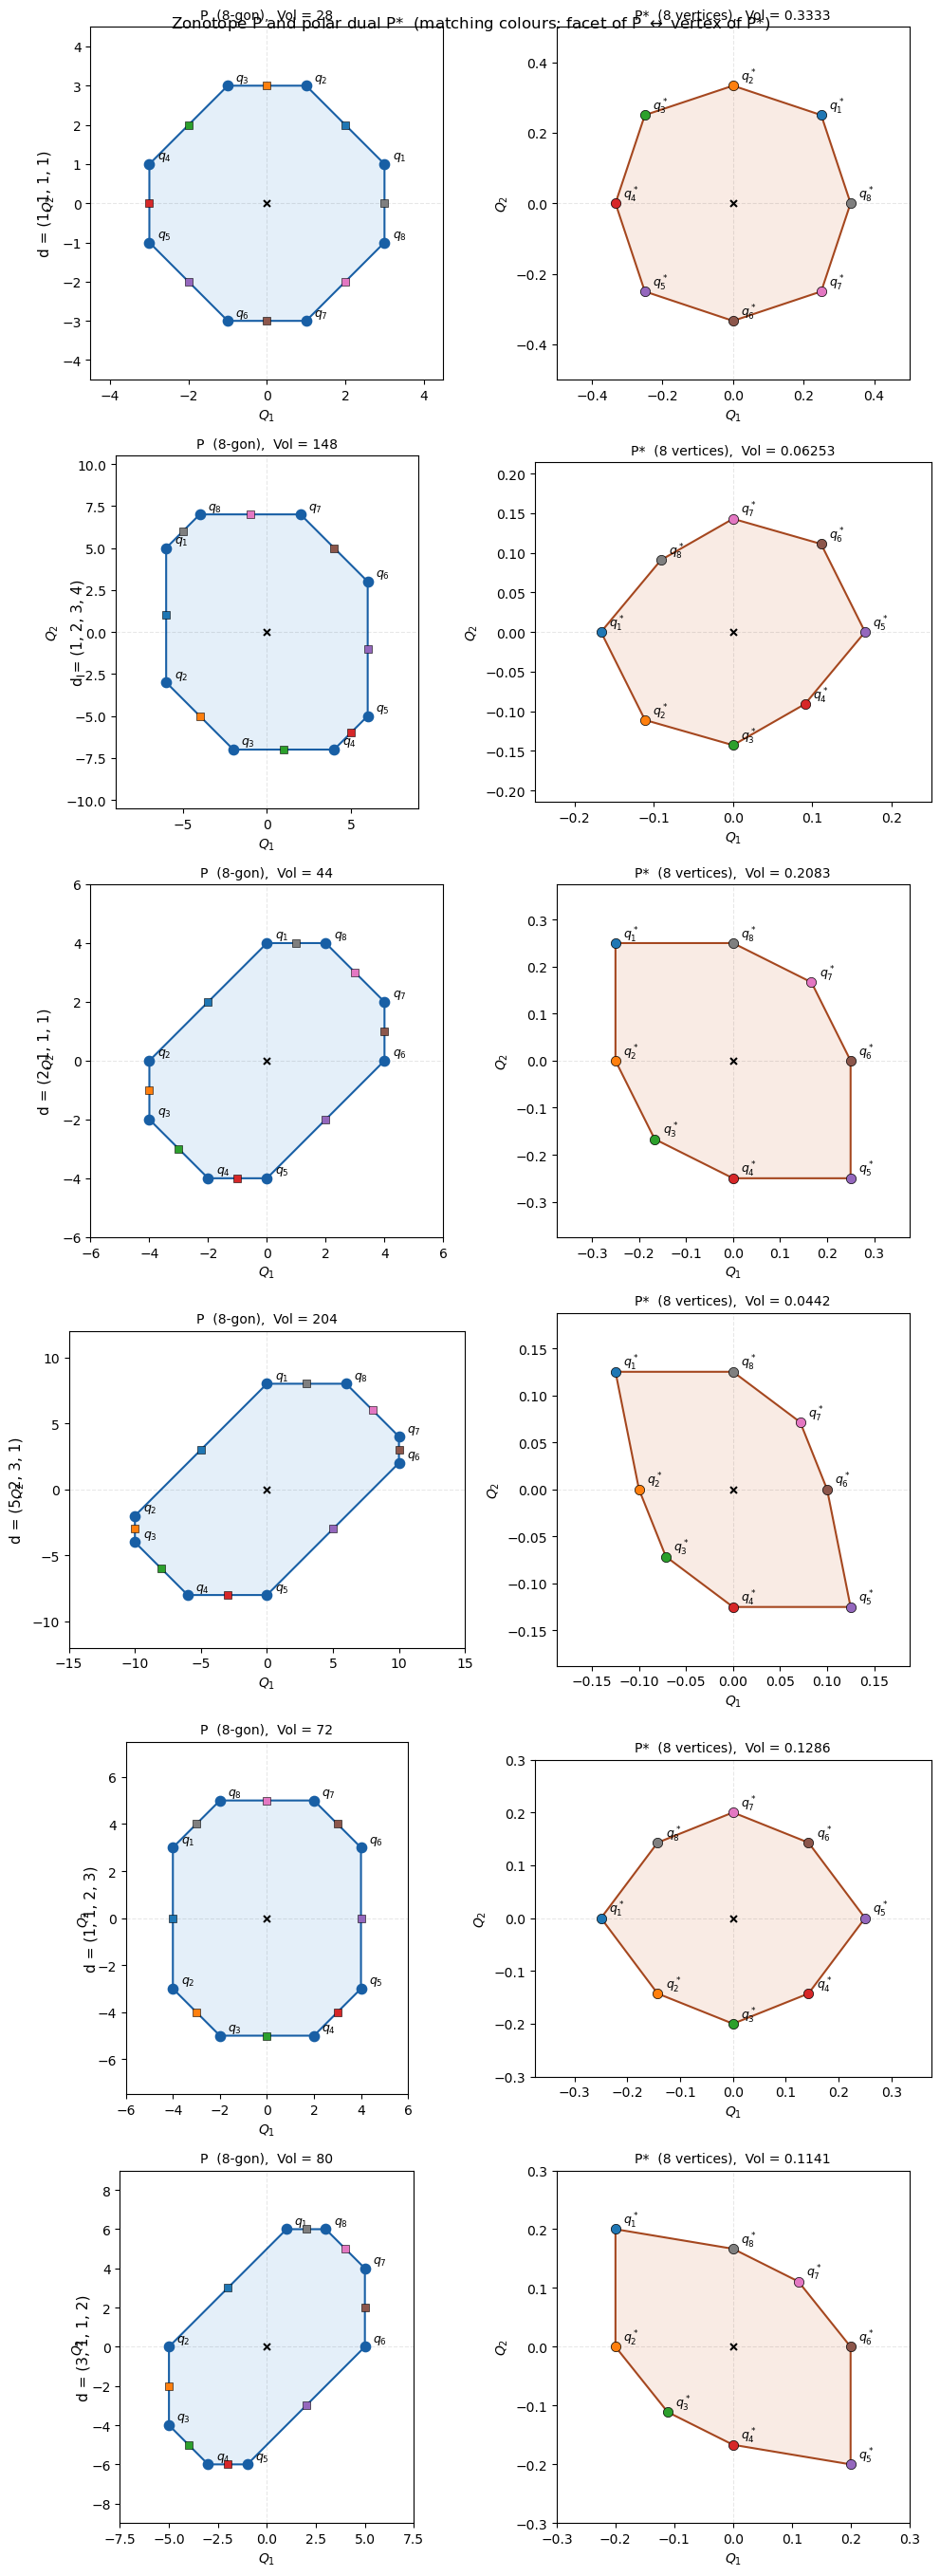

In [13]:
# ===========================================================================
# POLAR DUAL ANALYSIS
# ===========================================================================

def polar_dual(points, center=None, tol=1e-9, return_hull=False):
    """
    Polar dual of P = conv(points), valid in ANY dimension.

        P* = { y : v . y <= 1  for all v in P }

    Dual vertices are read off from the FACETS of P: a facet with outward
    normal n and offset c > 0 (facet plane n.x = c) contributes the dual
    vertex n / c.

    Generalizations over an edge-loop implementation:
      * vertices may be given in ANY order (hull computed internally);
      * interior points and collinear boundary points are handled
        automatically (Qhull drops them, so no duplicate dual vertices);
      * works in any dimension via ConvexHull facet equations;
      * optional `center`: dual taken about this point (default: origin;
        pass 'centroid' to use the vertex centroid; pass q0 to match the
        companion paper's convention P = Q^circ about q0).  The returned
        dual lives in the translated frame y -> y - center.

    Returns
    -------
    dual_verts : (n_facets, dim) array of dual vertices
                 (in 2D, ordered counter-clockwise)
    hull       : ConvexHull of the (translated) primal, if return_hull
    """
    pts = np.atleast_2d(np.asarray(points, dtype=float))
    dim = pts.shape[1]

    if center is None:
        c0 = np.zeros(dim)
    elif isinstance(center, str) and center == "centroid":
        c0 = pts.mean(axis=0)
    else:
        c0 = np.asarray(center, dtype=float)

    P = pts - c0
    hull = ConvexHull(P)

    # Qhull facet equations:  A x + b <= 0  for interior points.
    A = hull.equations[:, :-1]
    b = hull.equations[:, -1]
    if np.any(b > -tol):
        raise ValueError(
            "Center is not strictly interior to the polytope; "
            "polar dual has a vertex at infinity. Try center='centroid'.")

    dual = A / (-b)[:, None]                       # n / c per facet
    dual = np.unique(dual.round(12), axis=0)       # merge duplicate facets

    if dim == 2:                                   # order CCW for plotting
        ang = np.arctan2(dual[:, 1], dual[:, 0])
        dual = dual[np.argsort(ang)]

    return (dual, hull) if return_hull else dual


def volume(points):
    """Volume (area in 2D) of conv(points), any dimension."""
    pts = np.atleast_2d(np.asarray(points, dtype=float))
    return ConvexHull(pts).volume


# -- attach dual computation to the Zonotope class --------------------------

def _zonotope_polar_dual(self, orientations=None, center=None, tol=1e-9):
    """
    Polar dual P* of the zonotope P.  The dual is taken about q0 by
    default, matching the companion paper's convention P = Q^circ.
    Pass `orientations` to restrict to surviving (non-empty-cone) sign
    vectors, exactly as in Zonotope.vertices / Zonotope.analyse.
    """
    _, verts = self.vertices(orientations)
    c = self.q0 if center is None else center
    return polar_dual(verts, center=c, tol=tol)


Zonotope.polar_dual = _zonotope_polar_dual


# ---------------------------------------------------------------------------
# Reporting (dual)
# ---------------------------------------------------------------------------

def print_dual_table(z, orientations=None, factorial_dim=None):
    """
    Print primal hull vertices, their dual counterparts, and volumes,
    including the companion-paper normalisation  |F|! * Vol(P*).

    Parameters
    ----------
    z             : Zonotope (dim == 2 for the table layout)
    orientations  : optional restricted sign-vector list (e.g. only the
                    non-empty cones)
    factorial_dim : if given (e.g. |F| = 2), also prints
                    factorial_dim! * Vol(P*)
    """
    res = z.analyse(orientations)
    hull_pts = res["hull_pts"]
    dual = z.polar_dual(orientations)

    print(f"  Primal hull: {res['n_sides']}-gon,  "
          f"dual: {len(dual)} vertices")
    print(f"  {'primal vertex':^24} {'dual vertex':^28}")
    print("  " + "-" * 54)
    n = max(len(hull_pts), len(dual))
    for i in range(n):
        p = (f"({hull_pts[i, 0]:>7.3f}, {hull_pts[i, 1]:>7.3f})"
             if i < len(hull_pts) else "")
        d = (f"({dual[i, 0]:>10.6f}, {dual[i, 1]:>10.6f})"
             if i < len(dual) else "")
        print(f"  {p:^24} {d:^28}")

    vol_p = volume(hull_pts)
    vol_d = volume(dual)
    print(f"\n  Vol(P)  = {vol_p:.6f}")
    print(f"  Vol(P*) = {vol_d:.6f}")
    if factorial_dim:
        import math
        f = math.factorial(factorial_dim)
        print(f"  {factorial_dim}! * Vol(P*) = {f * vol_d:.6f}"
              f"   (companion-paper normalisation |F|! Vol)")
    print()


# ---------------------------------------------------------------------------
# Plot (primal + dual, 2D)
# ---------------------------------------------------------------------------

def plot_primal_dual(cases, orientations=None, figsize=None, titles=None):
    """
    Side-by-side plots of P and its polar dual P*, one row per case.
    Colours match: the k-th facet of P and the dual vertex it generates
    share a colour (facet midpoints are marked with coloured squares).

    Parameters
    ----------
    cases        : list of items; each item is a Zonotope or an
                   (n, 2) array of primal vertices
    orientations : optional sign-vector list applied to every Zonotope
                   in `cases` (e.g. the surviving non-empty cones)
    titles       : optional list of row titles
    """
    if not isinstance(cases, (list, tuple)):
        cases = [cases]
    n = len(cases)
    fig, axes = plt.subplots(n, 2, figsize=figsize or (10, 4.6 * n),
                             squeeze=False)
    cmap = plt.get_cmap("tab10")

    for r, case in enumerate(cases):
        if isinstance(case, Zonotope):
            res = case.analyse(orientations)
            hull_pts = res["hull_pts"]
            center = case.q0
        else:
            pts = np.asarray(case, dtype=float)
            h = ConvexHull(pts)
            hull_pts = pts[h.vertices]
            center = np.zeros(2)

        dual = polar_dual(hull_pts, center=center)
        axP, axD = axes[r]

        # ---------- primal ----------
        poly = plt.Polygon(hull_pts, closed=True,
                           facecolor="#3B8BD422", edgecolor="#185FA5",
                           linewidth=1.5, zorder=1)
        axP.add_patch(poly)
        axP.scatter(hull_pts[:, 0], hull_pts[:, 1],
                    color="#185FA5", s=55, zorder=3)
        for i, p in enumerate(hull_pts):
            axP.annotate(f"$q_{{{i + 1}}}$", p, textcoords="offset points",
                         xytext=(6, 4), fontsize=9)

        # facet midpoints coloured to match the dual vertices
        m = len(hull_pts)
        for i in range(m):
            a, b_ = hull_pts[i], hull_pts[(i + 1) % m]
            mid = 0.5 * (a + b_)
            axP.scatter(*mid, color=cmap(i % 10), s=36, marker="s",
                        zorder=4, edgecolors="k", linewidths=0.4)

        axP.scatter(*center, color="k", s=25, marker="x", zorder=5)
        axP.set_title(f"P  ({m}-gon),  Vol = {volume(hull_pts):.4g}",
                      fontsize=10)

        # ---------- dual ----------
        polyD = plt.Polygon(dual, closed=True,
                            facecolor="#D4703B22", edgecolor="#A5471F",
                            linewidth=1.5, zorder=1)
        axD.add_patch(polyD)
        # colour each dual vertex by the primal facet that generated it,
        # recomputed edge-by-edge so the colours line up with the squares
        for i in range(m):
            a, b_ = hull_pts[i], hull_pts[(i + 1) % m]
            edge = b_ - a
            nrm = np.array([edge[1], -edge[0]])
            c = np.dot(nrm, a - center)
            dv = nrm / c
            axD.scatter(*dv, color=cmap(i % 10), s=55, zorder=3,
                        edgecolors="k", linewidths=0.5)
            axD.annotate(f"$q^*_{{{i + 1}}}$", dv,
                         textcoords="offset points", xytext=(6, 4),
                         fontsize=9)
        axD.scatter(0, 0, color="k", s=25, marker="x", zorder=5)
        axD.set_title(f"P*  ({len(dual)} vertices),  "
                      f"Vol = {volume(dual):.4g}", fontsize=10)

        for ax in (axP, axD):
            ax.axhline(0, color="#00000018", linewidth=0.8, linestyle="--")
            ax.axvline(0, color="#00000018", linewidth=0.8, linestyle="--")
            ax.set_aspect("equal")
            ax.margins(0.25)
            ax.set_xlabel("$Q_1$")
            ax.set_ylabel("$Q_2$")

        if titles and r < len(titles):
            axP.text(-0.15, 0.5, titles[r], transform=axP.transAxes,
                     rotation=90, va="center", fontsize=11)

    fig.suptitle("Zonotope P and polar dual P*  "
                 "(matching colours: facet of P $\\leftrightarrow$ "
                 "vertex of P*)", fontsize=12)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Dual demo  (uses the module-level ORIENTATIONS / DIRS of the zonotope code)
# ---------------------------------------------------------------------------

if __name__ == "__main__":

    # sweep over the same d cases as the primal demo
    demo_cases = [[1, 1, 1, 1],
                  [1, 2, 3, 4],
                  [2, 1, 1, 1],
                  [5, 2, 3, 1],
                  [1, 1, 2, 3],
                  [3, 1, 1, 2]]
    zs = [Zonotope(DIRS, d=d) for d in demo_cases]
    for z_i in zs:
        print_dual_table(z_i, orientations=ORIENTATIONS, factorial_dim=2)

    fig = plot_primal_dual(zs, orientations=ORIENTATIONS,
                           titles=[f"d = {tuple(d)}" for d in demo_cases])
    out_path = "zonotope_duals.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved to {out_path}")
    plt.show()